In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
from sklearn import metrics

                           Email  \
0      mstephenson@fernandez.com   
1              hduke@hotmail.com   
2               pallen@yahoo.com   
3        riverarebecca@gmail.com   
4  mstephens@davidson-herman.com   

                                             Address            Avatar  \
0       835 Frank Tunnel\nWrightmouth, MI 82180-9605            Violet   
1     4547 Archer Common\nDiazchester, CA 06566-8576         DarkGreen   
2  24645 Valerie Unions Suite 582\nCobbborough, D...            Bisque   
3   1414 David Throughway\nPort Jason, OH 22070-1220       SaddleBrown   
4  14023 Rodriguez Passage\nPort Jacobville, PR 3...  MediumAquaMarine   

   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    

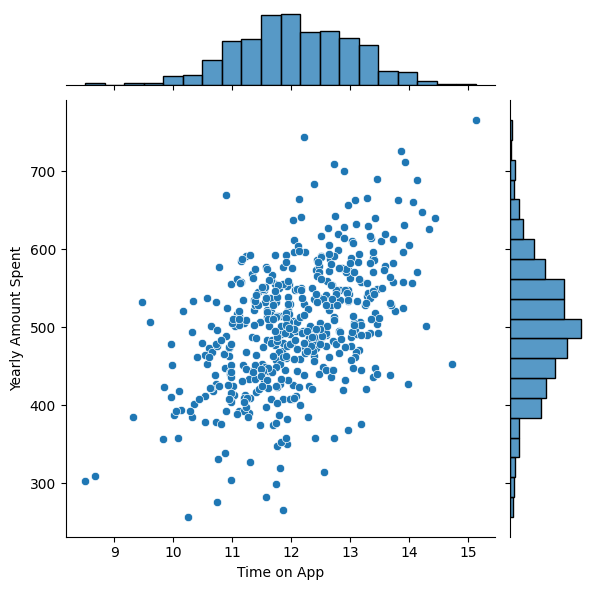

In [24]:
path = r"C:\Users\huawei\Downloads\Ecommerce Customers.csv"
df = pd.read_csv(path)

print(df.head())
print(df.info())
print(df.describe())

sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=df)
plt.show()

In [31]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [33]:
lm = LinearRegression()
lm.fit(X_train, y_train)

coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                      Coefficient
Avg. Session Length     25.981550
Time on App             38.590159
Time on Website          0.190405
Length of Membership    61.279097


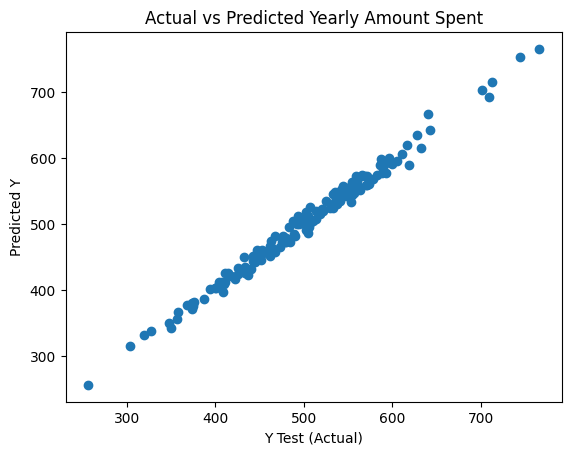

MAE: 7.228148653430826
MSE: 79.81305165097427
RMSE: 8.933815066978624


In [ ]:
predictions = lm.predict(X_test)

plt.scatter(y_test, predictions)
plt.xlabel('Y Test (Actual)')
plt.ylabel('Predicted Y')
plt.title('Actual vs Predicted Yearly Amount Spent')
plt.show()

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

In [30]:
sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title('Residuals Distribution')

Text(0.5, 1.0, 'Residuals Distribution')